# Scenario S3 & S4: Upper Bound Accuracy

**Goal:** Predict energy labels using complete real data to measure the marginal contribution of 3D geometry features.

- **S3** = bouwjaar + building type + TABULA U-values
- **S4** = S3 + 3D geometry (volume, envelope_area, shape_factor, building_height, num_floors)
- **S4 - S3** = marginal contribution of 3D geometry

In [3]:
import pandas as pd
import numpy as np
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import StratifiedKFold, cross_val_predict
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
from sklearn.preprocessing import LabelEncoder
import matplotlib.pyplot as plt
import seaborn as sns

# Load data
features_df = pd.read_parquet("../data/processed/residential_tabula_matched.parquet")
joined_df = pd.read_parquet("../data/processed/bag_3dbag_ep_joined.parquet", columns=["pand_id", "Energieklasse"])
df = features_df.merge(joined_df, on="pand_id", how="left")

print(f"Buildings: {len(df)}")
print(f"Columns: {list(df.columns)}")
print(f"\nEnergieklasse distribution:")
print(df["Energieklasse"].value_counts().sort_index())

Buildings: 3495
Columns: ['pand_id', 'volume', 'envelope_area', 'shape_factor', 'building_height', 'num_floors_estimated', 'floor_area_estimated', 'lod2_quality_flag', 'Gebouwtype', 'bouwjaar', 'tabula_building_type', 'tabula_period', 'u_wall', 'u_roof', 'u_floor', 'u_window', 'Energieklasse']

Energieklasse distribution:
Energieklasse
A        569
A+       224
A++       66
A+++      72
A++++      3
B        401
C        981
D        515
E        342
F        182
G        140
Name: count, dtype: int64


## 1. Prepare Labels

Merge A+/A++/A+++/A++++ into a single "A+" class, resulting in 8 classes.

Simplified label distribution:
label
A+    365
A     569
B     401
C     981
D     515
E     342
F     182
G     140
Name: count, dtype: int64


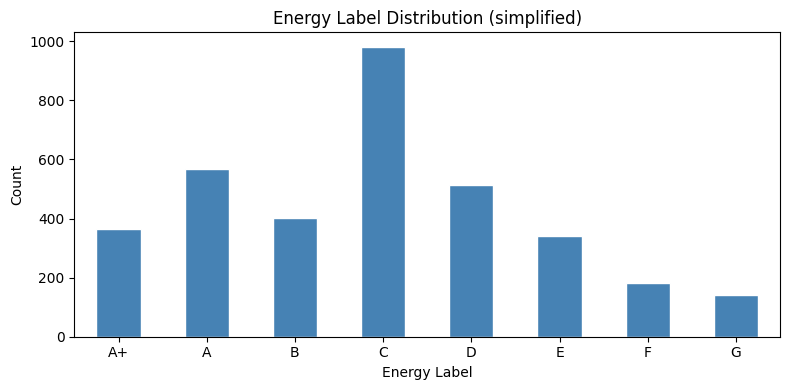

In [4]:
# Merge A+/A++/A+++/A++++ into "A+"
df["label"] = df["Energieklasse"].replace({
    "A++++": "A+",
    "A+++": "A+",
    "A++": "A+",
})

print("Simplified label distribution:")
label_order = ["A+", "A", "B", "C", "D", "E", "F", "G"]
label_counts = df["label"].value_counts().reindex(label_order)
print(label_counts)

fig, ax = plt.subplots(figsize=(8, 4))
label_counts.plot.bar(ax=ax, color="steelblue", edgecolor="white")
ax.set_title("Energy Label Distribution (simplified)")
ax.set_ylabel("Count")
ax.set_xlabel("Energy Label")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

## 2. Define Feature Sets & Train

In [5]:
# Encode target
le = LabelEncoder()
le.fit(label_order)
y = le.transform(df["label"])

# Encode tabula_building_type as numeric
type_map = {"SFH": 0, "TH": 1, "MFH": 2, "AB": 3}
df["building_type_encoded"] = df["tabula_building_type"].map(type_map)

# Feature sets
S3_FEATURES = ["bouwjaar", "building_type_encoded", "u_wall", "u_roof", "u_floor", "u_window"]
S4_FEATURES = S3_FEATURES + ["volume", "envelope_area", "shape_factor", "building_height", "num_floors_estimated"]

print(f"S3 features ({len(S3_FEATURES)}): {S3_FEATURES}")
print(f"S4 features ({len(S4_FEATURES)}): {S4_FEATURES}")

# Check for NaN
for name, feats in [("S3", S3_FEATURES), ("S4", S4_FEATURES)]:
    nan_count = df[feats].isna().sum().sum()
    print(f"{name} NaN count: {nan_count}")

S3 features (6): ['bouwjaar', 'building_type_encoded', 'u_wall', 'u_roof', 'u_floor', 'u_window']
S4 features (11): ['bouwjaar', 'building_type_encoded', 'u_wall', 'u_roof', 'u_floor', 'u_window', 'volume', 'envelope_area', 'shape_factor', 'building_height', 'num_floors_estimated']
S3 NaN count: 0
S4 NaN count: 0


In [6]:
# 5-fold stratified cross-validation with cross_val_predict
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

results = {}
predictions = {}

for name, feats in [("S3", S3_FEATURES), ("S4", S4_FEATURES)]:
    X = df[feats].values
    clf = RandomForestClassifier(
        n_estimators=200,
        class_weight="balanced",
        random_state=42,
        n_jobs=-1,
    )
    # cross_val_predict gives per-sample predictions across all folds
    y_pred = cross_val_predict(clf, X, y, cv=cv)
    acc = accuracy_score(y, y_pred)
    predictions[name] = y_pred
    
    # Also get per-fold accuracy for mean ± std
    fold_accs = []
    for train_idx, test_idx in cv.split(X, y):
        clf_fold = RandomForestClassifier(
            n_estimators=200, class_weight="balanced", random_state=42, n_jobs=-1
        )
        clf_fold.fit(X[train_idx], y[train_idx])
        fold_accs.append(accuracy_score(y[test_idx], clf_fold.predict(X[test_idx])))
    
    results[name] = {
        "accuracy": acc,
        "accuracy_mean": np.mean(fold_accs),
        "accuracy_std": np.std(fold_accs),
    }
    print(f"{name}: {np.mean(fold_accs):.4f} ± {np.std(fold_accs):.4f}")

print(f"\nMarginal contribution of 3D geometry: {results['S4']['accuracy'] - results['S3']['accuracy']:+.4f}")

S3: 0.3825 ± 0.0237
S4: 0.4670 ± 0.0115

Marginal contribution of 3D geometry: +0.0844


## 3. Accuracy Bar Chart

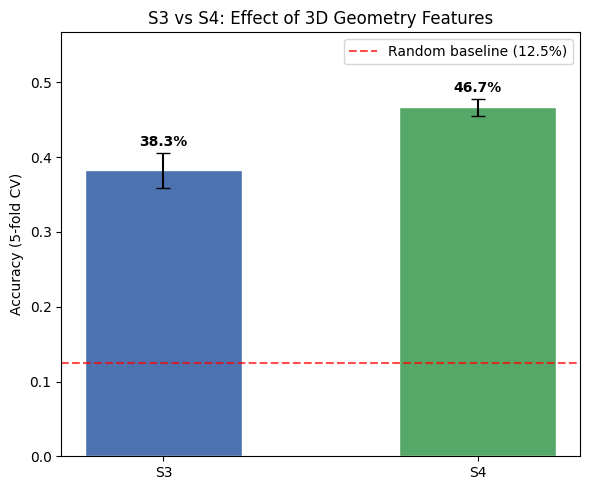

Random baseline (8 classes): 12.5%
S3 (registry + TABULA):  38.3%
S4 (+ 3D geometry):      46.7%
3D marginal contribution: +8.4%


In [7]:
fig, ax = plt.subplots(figsize=(6, 5))

scenarios = ["S3", "S4"]
means = [results[s]["accuracy_mean"] for s in scenarios]
stds = [results[s]["accuracy_std"] for s in scenarios]
colors = ["#4C72B0", "#55A868"]

bars = ax.bar(scenarios, means, yerr=stds, capsize=5, color=colors, edgecolor="white", width=0.5)

# Add value labels on bars
for bar, mean, std in zip(bars, means, stds):
    ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + std + 0.005,
            f"{mean:.1%}", ha="center", va="bottom", fontweight="bold")

# Random baseline
n_classes = len(label_order)
ax.axhline(y=1/n_classes, color="red", linestyle="--", alpha=0.7, label=f"Random baseline ({1/n_classes:.1%})")

ax.set_ylabel("Accuracy (5-fold CV)")
ax.set_title("S3 vs S4: Effect of 3D Geometry Features")
ax.set_ylim(0, max(means) + 0.1)
ax.legend()
plt.tight_layout()
plt.show()

print(f"Random baseline ({n_classes} classes): {1/n_classes:.1%}")
print(f"S3 (registry + TABULA):  {results['S3']['accuracy_mean']:.1%}")
print(f"S4 (+ 3D geometry):      {results['S4']['accuracy_mean']:.1%}")
print(f"3D marginal contribution: {results['S4']['accuracy_mean'] - results['S3']['accuracy_mean']:+.1%}")

## 4. Feature Importance

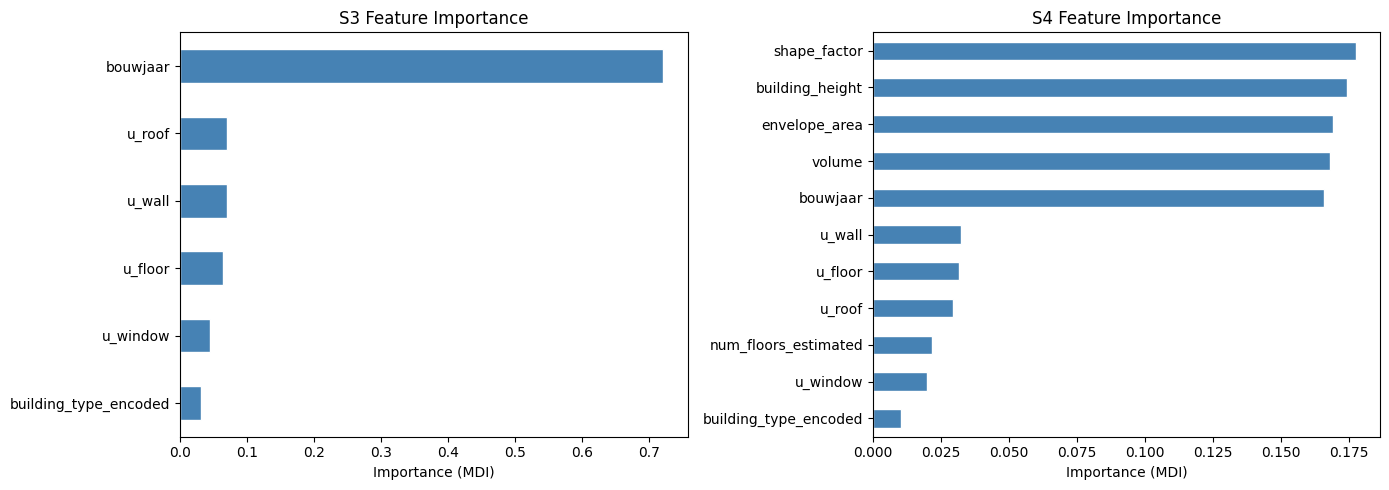

In [8]:
# Train final model on full data for feature importance
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for ax, (name, feats) in zip(axes, [("S3", S3_FEATURES), ("S4", S4_FEATURES)]):
    X = df[feats].values
    clf = RandomForestClassifier(
        n_estimators=200, class_weight="balanced", random_state=42, n_jobs=-1
    )
    clf.fit(X, y)
    
    importances = pd.Series(clf.feature_importances_, index=feats).sort_values()
    importances.plot.barh(ax=ax, color="steelblue", edgecolor="white")
    ax.set_title(f"{name} Feature Importance")
    ax.set_xlabel("Importance (MDI)")

plt.tight_layout()
plt.show()

## 5. Confusion Matrix

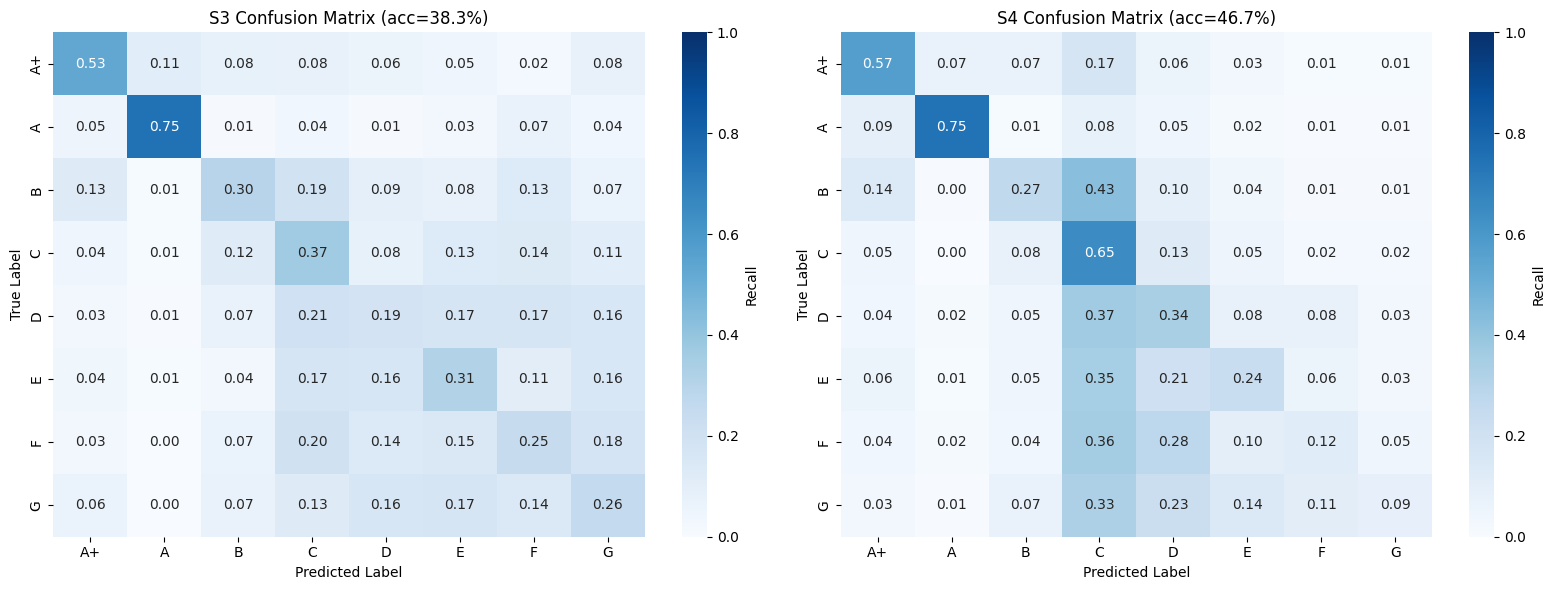

In [9]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

for ax, (name, y_pred) in zip(axes, predictions.items()):
    cm = confusion_matrix(y, y_pred)
    # Normalize by row (true label)
    cm_norm = cm.astype(float) / cm.sum(axis=1, keepdims=True)
    
    sns.heatmap(
        cm_norm, annot=True, fmt=".2f", cmap="Blues",
        xticklabels=label_order, yticklabels=label_order,
        ax=ax, vmin=0, vmax=1, cbar_kws={"label": "Recall"}
    )
    ax.set_title(f"{name} Confusion Matrix (acc={results[name]['accuracy']:.1%})")
    ax.set_ylabel("True Label")
    ax.set_xlabel("Predicted Label")

plt.tight_layout()
plt.show()

## 6. Classification Report

In [10]:
for name, y_pred in predictions.items():
    print(f"=== {name} ===")
    print(classification_report(y, y_pred, target_names=label_order))
    print()

=== S3 ===
              precision    recall  f1-score   support

          A+       0.66      0.53      0.59       569
           A       0.77      0.75      0.76       365
           B       0.33      0.30      0.31       401
           C       0.50      0.37      0.42       981
           D       0.27      0.19      0.22       515
           E       0.24      0.31      0.27       342
           F       0.11      0.25      0.15       182
           G       0.09      0.26      0.13       140

    accuracy                           0.38      3495
   macro avg       0.37      0.37      0.36      3495
weighted avg       0.44      0.38      0.40      3495


=== S4 ===
              precision    recall  f1-score   support

          A+       0.64      0.57      0.60       569
           A       0.81      0.75      0.78       365
           B       0.38      0.27      0.31       401
           C       0.47      0.65      0.54       981
           D       0.32      0.34      0.33       515
 